In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay


In [2]:
data_path = "../data/training.csv"
df = pd.read_csv(data_path)
df.shape

(250000, 33)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000000,162499.750000,224999.500000,287499.250000,349999.00000
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000000,78.100750,105.012000,130.606250,1192.02600
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000000,19.241000,46.524000,73.598000,690.07500
DER_mass_vis,250000.0,81.181982,40.828691,6.329000,59.388750,73.752000,92.259000,1349.35100
DER_pt_h,250000.0,57.895962,63.655682,0.000000,14.068750,38.467500,79.169000,2834.99900
DER_deltaeta_jet_jet,250000.0,-708.420675,454.480565,-999.000000,-999.000000,-999.000000,0.490000,8.50300
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000000,-999.000000,-999.000000,83.446000,4974.97900
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000000,-999.000000,-999.000000,-4.593000,16.69000
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208000,1.810000,2.491500,2.961000,5.68400
DER_pt_tot,250000.0,18.917332,22.273494,0.000000,2.841000,12.315500,27.591000,2834.99900


In [ ]:
df["Label"].value_counts(normalize=True)

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.373644,b
249996,349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,0.761439,b
249997,349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,...,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.005721,s
249998,349998,94.951,19.362,68.812,13.504,-999.00,-999.000,-999.000,3.365,13.504,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,0.512740,b


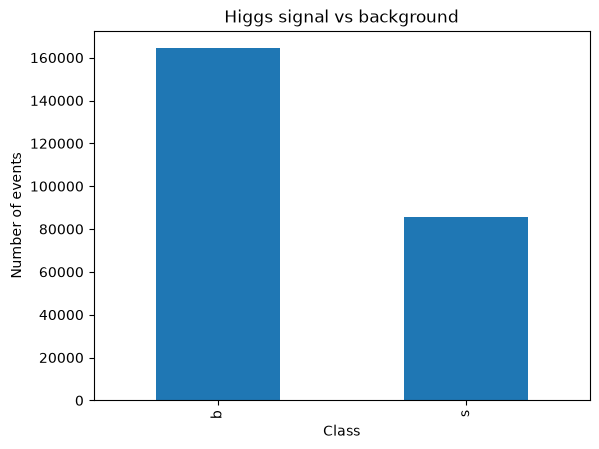

In [9]:
df["Label"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of events")
plt.title("Higgs signal vs background")
plt.show()

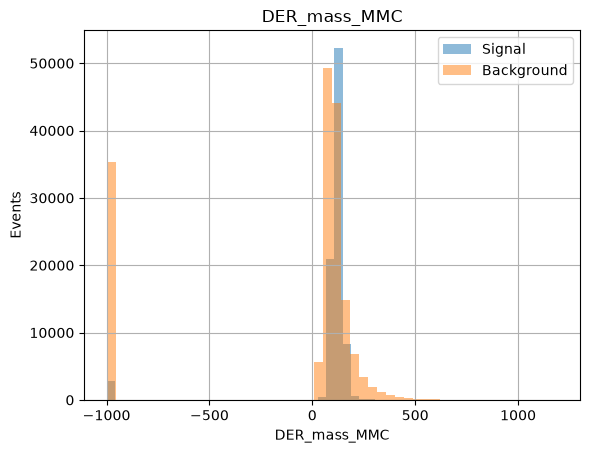

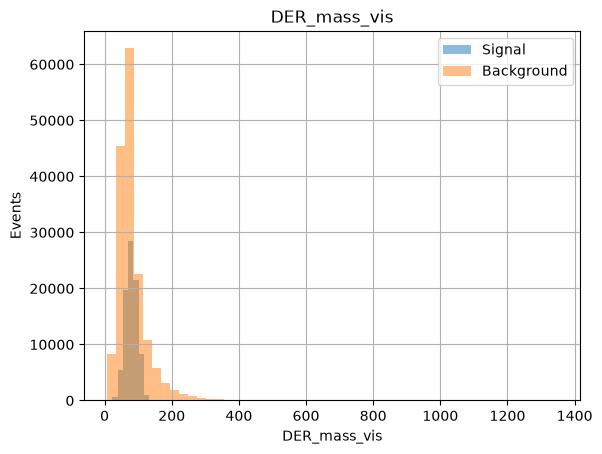

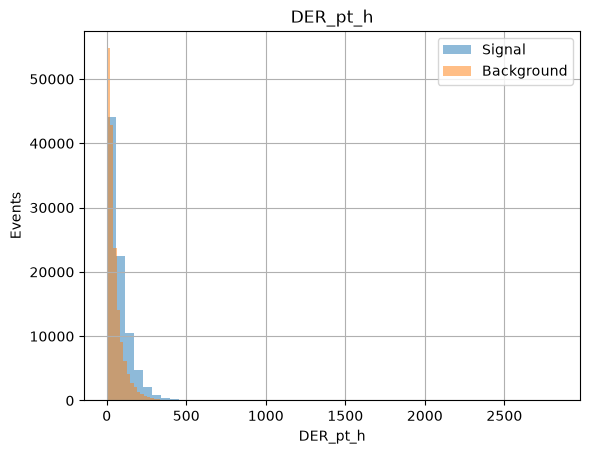

In [11]:
variables = [
    "DER_mass_MMC",
    "DER_mass_vis",
    "DER_pt_h",
]

for variable in variables:
    plt.figure()

    df[df["Label"] == "s"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Signal"
    )

    df[df["Label"] == "b"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Background"
    )

    plt.xlabel(variable)
    plt.ylabel("Events")
    plt.title(variable)
    plt.legend()

    plt.show()

In [12]:
missing_mmc = (df["DER_mass_MMC"] == -999)

print(f"Unavailable MMC values: {missing_mmc.sum():,}")
print(f"Fraction: {missing_mmc.mean():.1%}")

Unavailable MMC values: 38,114
Fraction: 15.2%


In [13]:
pd.crosstab(
    df["Label"],
    missing_mmc,
    normalize="index"
)

DER_mass_MMC,False,True
Label,,
b,0.785320,0.214680
s,0.966907,0.033093


In [17]:
feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns]
y = (df["Label"] == "s").astype(int)

print("Number of features:", X.shape[1])
print("Number of events:", X.shape[0])
print("Signal fraction:", y.mean())

Number of features: 30
Number of events: 250000
Signal fraction: 0.342668


In [19]:
(X == -999).sum().sort_values(ascending=False)

DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_lep_eta_centrality         177457
DER_prodeta_jet_jet            177457
PRI_jet_subleading_pt          177457
PRI_jet_subleading_phi         177457
PRI_jet_subleading_eta         177457
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_leading_phi             99913
DER_mass_MMC                    38114
DER_pt_h                            0
DER_mass_vis                        0
DER_mass_transverse_met_lep         0
PRI_tau_pt                          0
DER_met_phi_centrality              0
DER_pt_ratio_lep_tau                0
DER_sum_pt                          0
DER_deltar_tau_lep                  0
DER_pt_tot                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_met_sumet                       0
PRI_met_phi                         0
PRI_met                             0
PRI_lep_phi                         0
PRI_lep_eta 

In [22]:
X = X.replace(-999, np.nan)
X.isna().sum().sort_values(ascending=False)

DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_lep_eta_centrality         177457
DER_prodeta_jet_jet            177457
PRI_jet_subleading_pt          177457
PRI_jet_subleading_phi         177457
PRI_jet_subleading_eta         177457
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_leading_phi             99913
DER_mass_MMC                    38114
DER_pt_h                            0
DER_mass_vis                        0
DER_mass_transverse_met_lep         0
PRI_tau_pt                          0
DER_met_phi_centrality              0
DER_pt_ratio_lep_tau                0
DER_sum_pt                          0
DER_deltar_tau_lep                  0
DER_pt_tot                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_met_sumet                       0
PRI_met_phi                         0
PRI_met                             0
PRI_lep_phi                         0
PRI_lep_eta 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(y_train.mean())
print(y_test.mean())

0.34267
0.34266


In [28]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000)),
])
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['DER_mass_MMC','DER_mass_transverse_met_lep','DER_mass_vis',..., 'PRI_jet_subleading_eta','PRI_jet_subleading_phi','PRI_jet_all_pt']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to

In [29]:
y_score = logistic_model.predict_proba(X_test)[:, 1]

In [31]:
auc = roc_auc_score(y_test, y_score)
print(f"ROC-AUC = {auc:.4f}")

ROC-AUC = 0.8123


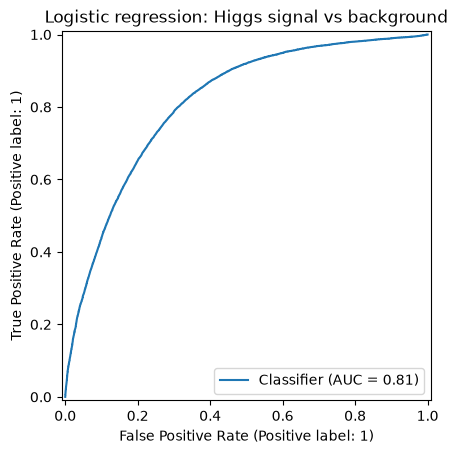

In [33]:
RocCurveDisplay.from_predictions(
    y_test,
    y_score,
)

plt.title("Logistic regression: Higgs signal vs background")
plt.show()